In [23]:
# --------------------------------------------------------------
#  Toyota 5-class CNN
# --------------------------------------------------------------

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import os
import time
from datetime import timedelta

# --------------------------  SEED  ---------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)          # for multi-GPU
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# --------------------------------------------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [24]:
# -----------------------  PARAMETERS  ------------------------
BATCH_SIZE       = 64   # batch size
IMAGE_SIZE       = 224  # 224x224 images
BASE_LR          = 3e-4 # base learning rate
WARMPUP_EPOCHS   = 3    # number of warm-up epochs
EPOCHS           = 200   # number of training epochs
WIDTH_FACTOR     = 1.50    # width factor for model channels
PATIENCE         = 10   # early stopping patience
DATA_ROOT        = "./toyota_intact_dataset"
SELECTED_CLASSES = ["avalon_v2", "venza_v2", "sienna_v2", "yaris_v2", "supra_v2"]
# --------------------------------------------------------------

In [25]:
# ---------------------  DATA PREP  ---------------------------
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),  # redimensiona la imagen
    transforms.RandomHorizontalFlip(p=0.5),  # voltea horizontalmente con probabilidad 0.5
    # transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.7, 1.0)),  # recorte y escalado aleatorio
    # transforms.RandomRotation(degrees=10),  # rotación a la imagen aleatoria
    # transforms.RandomCrop(IMAGE_SIZE, padding=4),  # recorta con padding aleatorio
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # altera color/contraste/tono
    transforms.ToTensor(),  # convierte PIL->Tensor y normaliza rango [0,1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # normaliza con medias de ImageNet
                         std =[0.229, 0.224, 0.225]),  # desviaciones estándar de ImageNet
])

# https://docs.pytorch.org/vision/stable/transforms.html#torchvision.transforms.Normalize
# for normalization, we use the standard ImageNet values

test_transform = transforms.Compose([  # transformaciones para validación/prueba (determinísticas)
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),  # redimensiona al tamaño objetivo
    transforms.CenterCrop(224),  # recorte central a 224x224
    transforms.ToTensor(),  # convierte a tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # normaliza con medias ImageNet
                         std =[0.229, 0.224, 0.225]),  # normaliza con std ImageNet
])

# Clase para filtrar las clases del dataset completo 
class FilteredToyotaDataset(Dataset):
    def __init__(self, root, selected, transform=None):  # inicializa el dataset filtrado
        full = ImageFolder(root)  # carga el dataset completo usando ImageFolder
        self.selected = selected  # lista de clases que queremos conservar
        self.class_to_idx = {c: i for i, c in enumerate(selected)}  # mapea clase->índice nuevo
        self.indices = []  # lista de índices filtrados
        self.old2new = {}  # mapeo de índices antiguos a nuevos
        processed = 0 
        
        print("Filtering dataset...")
        for cls in selected:  # para cada clase seleccionada
            old_idx = full.class_to_idx[cls]  # obtiene el índice original de la clase
            self.old2new[old_idx] = self.class_to_idx[cls]  # guarda el mapeo antiguo->nuevo
            class_indices = [i for i, (_, l) in enumerate(full) if l == old_idx]  # recoge índices de esa clase
            self.indices.extend(class_indices)  # extiende la lista de índices filtrados
            processed += len(class_indices)  # actualiza contador
            print(f"Filtered {len(class_indices)} out of {len(full)} images for class '{cls}' (total processed: {processed})")
        
        self.full = full  # guarda referencia al dataset completo
        self.transform = transform  # guarda la transformación a aplicar

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):  # obtiene un elemento por índice relativo al dataset filtrado
        i = self.indices[idx]  # índice en el dataset original
        img, old_label = self.full[i]  # carga imagen y etiqueta original
        new_label = self.old2new[old_label]  # convierte etiqueta al nuevo índice
        if self.transform:  # aplica transformaciones si se definieron
            img = self.transform(img)
        return img, new_label  # devuelve imagen transformada y nueva etiqueta

# carga el dataset filtrado y particiona
full_set = FilteredToyotaDataset(DATA_ROOT, SELECTED_CLASSES)  # instancia el dataset filtrado
print(f"Selected samples: {len(full_set)}")

train_len = int(0.8 * len(full_set)) # 80% train - longitud del conjunto de entrenamiento
val_len   = int(0.1 * len(full_set)) # 10% validation - longitud de validación
test_len  = len(full_set) - train_len - val_len # 10% test - longitud de prueba

# Dividimos el dataset de forma alteratoria pero reproducible usando la semilla
train_idx, val_idx, test_idx = random_split(
    range(len(full_set)),  # rango de índices del dataset completo
    [train_len, val_len, test_len],  # tamaños de cada partición
    generator=torch.Generator().manual_seed(SEED)
)

# Creamos los subsets correspondientes
train_set = Subset(full_set, train_idx)
val_set   = Subset(full_set, val_idx)
test_set  = Subset(full_set, test_idx)

# Aplicamos las transformaciones predefinidas a cada subset  # envoltorio para aplicar transformaciones
class TransformSubset(Dataset):  # clase auxiliar que aplica transform a un Subset
    def __init__(self, subset, transform):
        self.subset = subset  # almacena el subset original
        self.transform = transform  # almacena la transformacion a aplicar
    def __len__(self): return len(self.subset)  # retorna tamaño del subset
    def __getitem__(self, i):
        img, label = self.subset[i]  # obtiene par (img, label) desde el subset
        if self.transform: img = self.transform(img)  # aplica transform si existe
        return img, label  # devuelve la muestra transformada

train_set = TransformSubset(train_set, train_transform)  # aplica transformaciones de entrenamiento
val_set   = TransformSubset(val_set,   test_transform)  # aplica transformaciones de validación
test_set  = TransformSubset(test_set,  test_transform)  # aplica transformaciones de prueba

# DataLoaders para iteración en batches
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  # loader de entrenamiento con shuffle
                          generator=torch.Generator().manual_seed(SEED))
dev_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)  # loader de validación
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)  # loader de prueba
# --------------------------------------------------------------

Filtering dataset...


c:\dev\coding-projects\toyota-cnn-classifier\.venv\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Filtered 425 out of 18603 images for class 'avalon_v2' (total processed: 425)
Filtered 103 out of 18603 images for class 'venza_v2' (total processed: 528)
Filtered 550 out of 18603 images for class 'sienna_v2' (total processed: 1078)
Filtered 720 out of 18603 images for class 'yaris_v2' (total processed: 1798)
Filtered 165 out of 18603 images for class 'supra_v2' (total processed: 1963)
Selected samples: 1963


In [26]:
# --------------------------  MODEL  --------------------------- 
class ToyotaCNN_32x32(nn.Module):  # arquitectura pequeña para imágenes 32x32
    def __init__(self, n_classes=5):
        super().__init__()
        self.conv1 = nn.Conv2d(3,   64, 3, padding=1)  # primera convolución 3->64
        self.bn1   = nn.BatchNorm2d(64)  # batchnorm para la primera capa
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)  # segunda convolución 64->128
        self.bn2   = nn.BatchNorm2d(128)  # batchnorm segunda
        self.conv3 = nn.Conv2d(128,256, 3, padding=1)  # tercera convolución 128->256
        self.bn3   = nn.BatchNorm2d(256)  # batchnorm tercera

        self.pool  = nn.MaxPool2d(2, 2)  # pooling 2x2
        self.drop  = nn.Dropout(0.5)  # dropout para regularización

        self.fc1   = nn.Linear(256*4*4, 512)  # capa totalmente conectada intermedia
        self.bnfc  = nn.BatchNorm1d(512)  # batchnorm para la FC
        self.fc2   = nn.Linear(512, n_classes)  # capa final de clasificación

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # 32 → 16  # conv+bn+relu+pool
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # 16 → 8
        x = self.pool(F.relu(self.bn3(self.conv3(x))))   # 8  → 4
        x = x.view(-1, 256*4*4)  # aplana para FC
        x = self.drop(x)  # aplica dropout
        x = F.relu(self.bnfc(self.fc1(x)))  # FC intermedia + BN + ReLU
        x = self.drop(x)  # dropout otra vez
        x = self.fc2(x)  # logits finales
        return x  # retorna logits
    
class ToyotaCNN_64x64(nn.Module):  # arquitectura media para 64x64
    def __init__(self, n_classes=5):
        super().__init__()
        self.features = nn.Sequential(  # bloque de extracción de características
            # Block 1
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),  # conv-bn-relu
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),  # segunda conv del bloque
            nn.MaxPool2d(2), # 64x64 -> 32x32  # reduce dimensionalidad
            # Block 2
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), # 32x32 -> 16x16
            # Block 3
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),  # 16 → 8
        )
        
        self.classifier = nn.Sequential(  # clasificador fully-connected
            nn.Dropout(0.5),  # dropout inicial
            nn.Linear(256 * 8 * 8, 512), nn.ReLU(), nn.BatchNorm1d(512),  # FC+ReLU+BN
            nn.Dropout(0.3),  # dropout adicional
            nn.Linear(512, n_classes)  # salida de logits
        )
        
    def forward(self, x):
        x = self.features(x)  # pasa por extractor de caracteristicas
        x = x.view(x.size(0), -1)  # aplana manteniendo batch size
        return self.classifier(x)  # retorna logits de clasificación

class ToyotaCNN_man(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),  # 224 -> 112
            
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),  # 112 -> 56
            nn.Dropout(0.25),
            
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),  # 56 -> 28
            nn.Dropout(0.25),
            
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),  # 28 -> 14
            nn.Dropout(0.25),
            
            # nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            # nn.MaxPool2d(2),  # 14 -> 7
            # nn.Dropout(0.25),
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 1024), nn.ReLU(), nn.BatchNorm1d(1024),
            nn.Dropout(0.5),
            nn.Linear(1024, n_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)
    
class ToyotaCNN_Lite(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.n_classes = n_classes
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2), # Moderate dropout
            
            # Block 3 (Stop expanding here! No need for 256/512 filters)
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),
        )
        
        self.classifier = nn.Sequential(
            # Flatten size calculation: 224 -> 112 -> 56 -> 28
            nn.Linear(128 * 28 * 28, 512), 
            nn.ReLU(), 
            nn.BatchNorm1d(512),
            nn.Dropout(0.5), # High dropout in classifier is good
            nn.Linear(512, n_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)
    
class ToyotaCNN_GAP(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        
        # Block 1: Detect edges
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2) # 224 -> 112
        )
        
        # Block 2: Detect shapes
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2) # 112 -> 56
        )
        
        # Block 3: Detect car parts
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2) # 56 -> 28
        )
        
        # Block 4: High level features (Lights, Grills)
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            # Note: We stop pooling here to keep spatial info for the GAP
        )

        # THE MAGIC SAUCE: Global Average Pooling
        # This takes the 28x28 feature maps and averages them to 1x1
        self.global_pool = nn.AdaptiveAvgPool2d(1) 
        
        # Classifier is now tiny and hard to overfit
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5), # Keep dropout high
            nn.Linear(256, n_classes) # No massive hidden layers
        )
        
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.global_pool(x)
        return self.classifier(x)
    
class ConvBNReLU(nn.Sequential):  # bloque conv->bn->relu reutilizable
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, padding=1):
        super().__init__(
            nn.Conv2d(in_ch, out_ch, kernel, stride=stride, padding=padding, bias=False),  # conv sin bias
            nn.BatchNorm2d(out_ch),  # batchnorm
            nn.ReLU(inplace=True)  # activación in-place
        )

class ResidualBlock(nn.Module):  # bloque con skip connections (no fully connected) que ayuda a entrenar redes profundas
    def __init__(self, in_ch, out_ch, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False)  # primera conv
        self.bn1   = nn.BatchNorm2d(out_ch)  # bn primera
        self.relu  = nn.ReLU(inplace=True)  # relu in-place
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False)  # segunda conv
        self.bn2   = nn.BatchNorm2d(out_ch)  # bn segunda
        self.downsample = downsample  # capa de downsample para identidad

    def forward(self, x):
        identity = x  # guarda la identidad
        out = self.conv1(x)  # conv1
        out = self.bn1(out)  # bn1
        out = self.relu(out)  # relu
        out = self.conv2(out)  # conv2
        out = self.bn2(out)  # bn2

        if self.downsample is not None:  # si es necesario ajustar la identidad
            identity = self.downsample(x)  # aplica downsample

        out += identity  # suma skip connection
        return self.relu(out)  # activación final y retorno

class ToyotaCNN_224x224(nn.Module):  # arquitectura para imágenes 224x224
    def __init__(self, n_classes=5, width_factor=WIDTH_FACTOR, no_custom_weight_init=False):
        super().__init__()
        wf = lambda c: max(8, int(c * width_factor))  # función para escalar canales
        self.in_ch = wf(32)  # canales iniciales escalados
        self.stem = nn.Sequential(  # bloque inicial (stem)
            nn.Conv2d(3, self.in_ch, kernel_size=7, stride=2, padding=3, bias=False),  # conv 7x7
            nn.BatchNorm2d(self.in_ch),  # bn del stem
            nn.ReLU(inplace=True),  # relu
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),  # reduce resolución
        )

        stages = [  # definición de etapas: (out_channels, numero_de_bloques, stride_inicial)
            (wf(32), 2, 1),
            (wf(64), 2, 2),
            (wf(128), 2, 2),
            (wf(256), 2, 2),
            (wf(512), 1, 2),
        ]

        layers = []  # lista acumuladora de bloques
        in_ch = self.in_ch  # canales de entrada iniciales
        for out_ch, blocks, stride in stages:  # construye cada etapa
            downsample = None  # por defecto no hay downsample
            if stride != 1 or in_ch != out_ch:  # si cambia tamaño o canales
                downsample = nn.Sequential(  # crea operación de ajuste para la identidad
                    nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                    nn.BatchNorm2d(out_ch),
                )
            layers.append(ResidualBlock(in_ch, out_ch, stride=stride, downsample=downsample))  # primer bloque de la etapa
            for _ in range(1, blocks):  # bloques restantes de la etapa
                layers.append(ResidualBlock(out_ch, out_ch))  # bloques sin downsample
            in_ch = out_ch  # actualiza canales de entrada para la siguiente etapa

        self.features = nn.Sequential(*layers)  # secuencia de bloques residuales
        self.global_pool = nn.AdaptiveAvgPool2d(1) # pooling global para reducir overfitting
        self.dropout = nn.Dropout(0.4)  # dropout antes del fully connected
        self.fc = nn.Linear(in_ch, n_classes)  # capa final de clasificación

        if not no_custom_weight_init:
            self._init_weights()  # inicializa pesos personalizados

    def _init_weights(self):
        for m in self.modules():  # recorre submódulos
            if isinstance(m, nn.Conv2d):  # inicializa convoluciones
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu') # He inicialización
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):  # inicializa normas
                if getattr(m, 'weight', None) is not None:
                    nn.init.constant_(m.weight, 1)  # peso a 1
                if getattr(m, 'bias', None) is not None:
                    nn.init.constant_(m.bias, 0)  # bias a 0
            elif isinstance(m, nn.Linear):  # inicializa lineales
                nn.init.normal_(m.weight, 0, 0.01)  # pequeña desviación normal
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)  # bias a 0

    def forward(self, x):  # paso forward final
        x = self.stem(x)  # pasa por stem
        x = self.features(x)  # pasa por bloques residuales
        x = self.global_pool(x)  # pooling global para obtener (Batch, Channels, 1, 1)
        x = torch.flatten(x, 1)  # aplana a (Batch, Channels)
        x = self.dropout(x)  # aplica dropout
        return self.fc(x)  # retorna logits finales
# --------------------------------------------------------------  # fin de modelos

In [27]:
# ---------------------  TRAINING HELPERS  --------------------
def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            pred = out.argmax(dim=1)
            correct += (pred == y).sum().item()
            total   += y.size(0)
    return 100.0 * correct / total if total else 0.0

def train_one_epoch(epoch, model, loader, crit, opt, scheduler, warmup_epochs=WARMPUP_EPOCHS, base_lr=BASE_LR):
    model.train()
    running_loss = correct = total = 0.0

    # ----- LR warm-up (linear) -----
    if epoch <= warmup_epochs:
        lr = base_lr * epoch / warmup_epochs
        for g in opt.param_groups:
            g['lr'] = lr

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()

        out = model(x)
        loss = crit(out, y)
        pred = out.argmax(dim=1)
        correct += (pred == y).sum().item()

        loss.backward()
        opt.step()

        running_loss += loss.item()
        total   += y.size(0)

    # ----- Step the cosine scheduler after warm-up -----
    if epoch > warmup_epochs:
        scheduler.step()  # avanza el scheduler de LR

    acc = 100.0 * correct / total if total > 0 else 0  # calcula accuracy
    return running_loss / len(loader), acc  # devuelve pérdida media y accuracy

def validate(model, loader, crit):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = crit(out, y)
            running_loss += loss.item()
    return running_loss / len(loader)

def balanced_weights(n_classes=5):
        # Calculate class weights based on training set distribution
        class_counts = [0] * n_classes
        for _, label in train_set:
            class_counts[label] += 1
        
        counts = torch.tensor(class_counts, dtype=torch.float)
        weights = 1.0 / counts
        weights = weights / weights.sum()
        weights = weights.to(DEVICE)
        print("Class weights:", weights)
        return weights
# --------------------------------------------------------------

Starting training at:  2025-12-03 13:06:44
[Epoch 01 | 0:00:15 (15.07s) | p=0/10] train_loss: 1.490 | train_acc: 34.97% | dev_loss: 1.407 | dev_acc: 37.24%
[Epoch 02 | 0:00:14 (14.08s) | p=0/10] train_loss: 1.368 | train_acc: 42.87% | dev_loss: 1.275 | dev_acc: 41.84%
[Epoch 03 | 0:00:14 (14.53s) | p=1/10] train_loss: 1.238 | train_acc: 54.84% | dev_loss: 1.413 | dev_acc: 46.94%
[Epoch 04 | 0:00:14 (14.78s) | p=0/10] train_loss: 1.126 | train_acc: 62.36% | dev_loss: 1.194 | dev_acc: 51.53%
[Epoch 05 | LR] Current LR: 0.0002999259840548597
[Epoch 05 | 0:00:14 (14.96s) | p=1/10] train_loss: 0.992 | train_acc: 69.87% | dev_loss: 1.204 | dev_acc: 57.65%
[Epoch 06 | 0:00:14 (14.85s) | p=0/10] train_loss: 0.835 | train_acc: 79.49% | dev_loss: 1.165 | dev_acc: 58.67%
[Epoch 07 | 0:00:14 (14.85s) | p=1/10] train_loss: 0.732 | train_acc: 84.71% | dev_loss: 1.188 | dev_acc: 59.69%
[Epoch 08 | 0:00:14 (14.79s) | p=2/10] train_loss: 0.664 | train_acc: 88.28% | dev_loss: 1.207 | dev_acc: 63.27%
[Ep

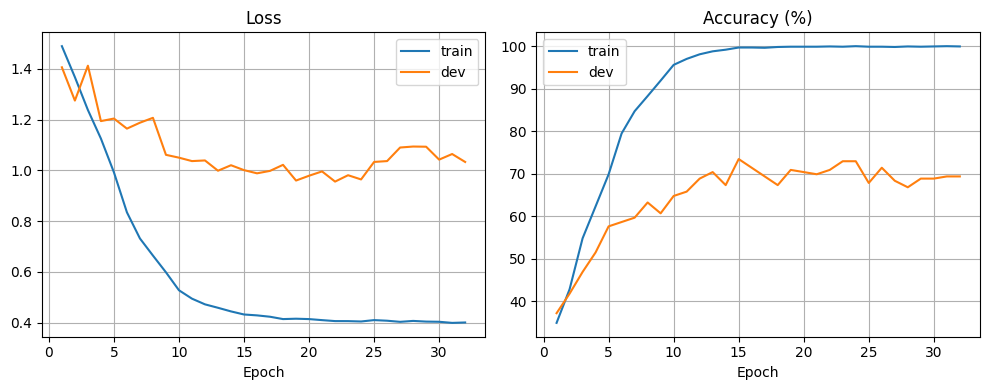


=== TOTAL TRAINING TIME: 0:08:02 (482.16s) ===

=== FINAL TEST ACCURACY: 59.90% ===


In [32]:
# --------------------------  RUN  ---------------------------
model = ToyotaCNN_224x224(n_classes=len(SELECTED_CLASSES), no_custom_weight_init=False).to(DEVICE)
# model = ToyotaCNN_GAP(n_classes=len(SELECTED_CLASSES)).to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=BASE_LR, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {"train_loss": [], "train_acc": [], "dev_loss": [], "dev_acc": []}

best_dev = 5
wait = 0

# tiempo inicial paara grabar cuanto dura el entrenamiento
start_time = time.time()
print("Starting training at: ", time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(start_time)))

for epoch in range(1, EPOCHS + 1):
    # timestamp de la epoch actual
    epoch_start = time.time()
    start_str = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(epoch_start))

    tr_loss, tr_acc = train_one_epoch(
        epoch, model, train_loader, criterion, optimizer,
        scheduler, warmup_epochs=WARMPUP_EPOCHS,
        base_lr=BASE_LR)
    dev_loss = validate(model, dev_loader, criterion)
    dev_acc  = evaluate(model, dev_loader)
    
    if epoch % 5 == 0:
        print(f"[Epoch {epoch:02d} | LR] Current LR:", optimizer.param_groups[0]['lr'])

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["dev_loss"].append(dev_loss)
    history["dev_acc"].append(dev_acc)

    # duracion de la actual epoch
    epoch_time = time.time() - epoch_start
    
    if dev_loss < best_dev:
        best_dev = dev_loss
        torch.save(model.state_dict(), f'models/best_model_{epoch}.pt')
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE: 
            print(f"[Epoch {epoch:02d} | {timedelta(seconds=int(epoch_time))} ({epoch_time:.2f}s) | p={wait}/{PATIENCE}] "
          f"train_loss: {tr_loss:.3f} | train_acc: {tr_acc:5.2f}% | "
          f"dev_loss: {dev_loss:.3f} | dev_acc: {dev_acc:5.2f}%")
            print(f"Training ran out of patience ({wait}/{PATIENCE} patience). Early stopping.")
            break
    
    print(f"[Epoch {epoch:02d} | {timedelta(seconds=int(epoch_time))} ({epoch_time:.2f}s) | p={wait}/{PATIENCE}] "
          f"train_loss: {tr_loss:.3f} | train_acc: {tr_acc:5.2f}% | "
          f"dev_loss: {dev_loss:.3f} | dev_acc: {dev_acc:5.2f}%")

# -----------------------  PLOTS  -------------------------
def plot_history(h):
    ep = range(1, len(h["train_loss"]) + 1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(ep, h["train_loss"], label="train")
    plt.plot(ep, h["dev_loss"],   label="dev")
    plt.title("Loss"); plt.xlabel("Epoch"); plt.legend(); plt.grid()
    plt.subplot(1,2,2)
    plt.plot(ep, h["train_acc"], label="train")
    plt.plot(ep, h["dev_acc"],   label="dev")
    plt.title("Accuracy (%)"); plt.xlabel("Epoch"); plt.legend(); plt.grid()
    plt.tight_layout(); plt.show()

plot_history(history)

# reportar tiempo total de entrenamiento
total_time = time.time() - start_time
print(f"\n=== TOTAL TRAINING TIME: {timedelta(seconds=int(total_time))} ({total_time:.2f}s) ===")

# ---------------------  FINAL TEST  ----------------------
test_acc = evaluate(model, test_loader)
print(f"\n=== FINAL TEST ACCURACY: {test_acc:.2f}% ===")
# --------------------------------------------------------------


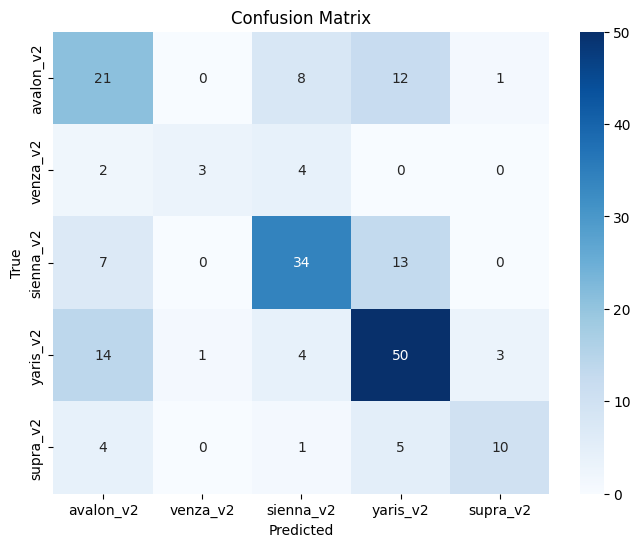

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            out = model(x)
            preds = out.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
    
plot_confusion_matrix(model, test_loader, SELECTED_CLASSES)

Starting training at:  2025-12-03 12:49:13
[Epoch 01 | 0:00:15 (15.66s)] train_loss: 1.323 | train_acc: 51.59% | dev_loss: 0.872 | dev_acc: 72.96%
[Epoch 02 | 0:00:14 (14.96s)] train_loss: 0.757 | train_acc: 84.20% | dev_loss: 0.728 | dev_acc: 87.24%
[Epoch 03 | 0:00:15 (15.08s)] train_loss: 0.578 | train_acc: 94.14% | dev_loss: 0.652 | dev_acc: 89.80%
[Epoch 04 | 0:00:14 (14.99s)] train_loss: 0.506 | train_acc: 98.41% | dev_loss: 0.613 | dev_acc: 91.33%
[Epoch 05 | LR] Current LR: 0.00029992371279000487
[Epoch 05 | 0:00:15 (15.02s)] train_loss: 0.480 | train_acc: 98.98% | dev_loss: 0.596 | dev_acc: 92.86%
[Epoch 06 | 0:00:15 (15.02s)] train_loss: 0.471 | train_acc: 99.43% | dev_loss: 0.605 | dev_acc: 91.33%
[Epoch 07 | 0:00:14 (14.99s)] train_loss: 0.459 | train_acc: 99.55% | dev_loss: 0.621 | dev_acc: 90.82%
[Epoch 08 | 0:00:14 (14.79s)] train_loss: 0.451 | train_acc: 99.81% | dev_loss: 0.607 | dev_acc: 91.33%
[Epoch 09 | 0:00:14 (14.92s)] train_loss: 0.448 | train_acc: 99.87% | dev_

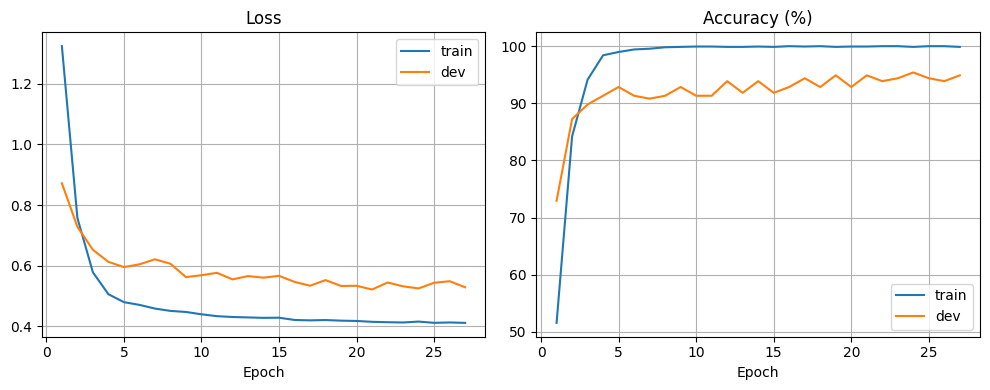

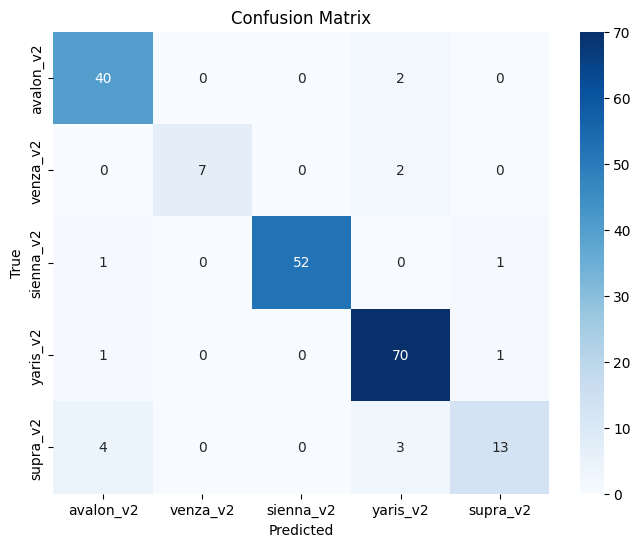

In [30]:
# -------------------- VIA TRANSFER LEARNING --------------------
# Cargar un modelo preentrenado (ResNet18)
pretrained_model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
num_ftrs = pretrained_model.fc.in_features
pretrained_model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, len(SELECTED_CLASSES))  # ajustar la capa final
)

model = pretrained_model.to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMPUP_EPOCHS)

history = {"train_loss": [], "train_acc": [], "dev_loss": [], "dev_acc": []}

best_dev = 5
patience = 6
wait = 0

# tiempo inicial paara grabar cuanto dura el entrenamiento
start_time = time.time()
print("Starting training at: ", time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(start_time)))

for epoch in range(1, EPOCHS + 1):
    # timestamp de la epoch actual
    epoch_start = time.time()
    start_str = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(epoch_start))

    tr_loss, tr_acc = train_one_epoch(
        epoch, model, train_loader, criterion, optimizer,
        scheduler, warmup_epochs=WARMPUP_EPOCHS,
        base_lr=BASE_LR)
    dev_loss = validate(model, dev_loader, criterion)
    dev_acc  = evaluate(model, dev_loader)
    
    if epoch % 5 == 0:
        print(f"[Epoch {epoch:02d} | LR] Current LR:", optimizer.param_groups[0]['lr'])

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["dev_loss"].append(dev_loss)
    history["dev_acc"].append(dev_acc)

    # duracion de la actual epoch
    epoch_time = time.time() - epoch_start
    print(f"[Epoch {epoch:02d} | {timedelta(seconds=int(epoch_time))} ({epoch_time:.2f}s)] "
          f"train_loss: {tr_loss:.3f} | train_acc: {tr_acc:5.2f}% | "
          f"dev_loss: {dev_loss:.3f} | dev_acc: {dev_acc:5.2f}%")
    
    if dev_loss < best_dev:
        best_dev = dev_loss
        torch.save(model.state_dict(), f'models/transfer_learning/best_model_{epoch}.pt')
        wait = 0
    else:
        wait += 1
        if wait >= patience: 
            print(f"Training ran out of patience ({wait}/{patience} patience). Early stopping.")
            break
        
total_time = time.time() - start_time
print(f"\n=== TOTAL TRAINING TIME: {timedelta(seconds=int(total_time))} ({total_time:.2f}s) ===")

# ---------------------  FINAL TEST  ----------------------
test_acc = evaluate(model, test_loader)
print(f"\n=== FINAL TEST ACCURACY: {test_acc:.2f}% ===")
# --------------------------------------------------------------

plot_history(history)
plot_confusion_matrix(model, test_loader, SELECTED_CLASSES)

In [31]:
# (optional) save best model
if dev_acc > max(history["dev_acc"][:-1] or [0]):
    torch.save(model.state_dict(), "models/best_cnn_warmup_cosine.pt")